In [44]:
import jax.numpy as np
import numpyro.distributions as dist
from jax import random, vmap
import numpyro.handlers as handlers
import numpyro
import pandas as pd
import matplotlib.pyplot as plt

# Example data
Waffle divorce dataset

In [5]:
DATASET_URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/WaffleDivorce.csv"
dset = pd.read_csv(DATASET_URL, sep=";")
dset

,Location,Loc,Population,MedianAgeMarriage,Marriage,Marriage SE,Divorce,Divorce SE,WaffleHouses,South,Slaves1860,Population1860,PropSlaves1860
0,Alabama,AL,4.78,25.3,20.2,1.27,12.7,0.79,128,1,435080,964201,0.450000
1,Alaska,AK,0.71,25.2,26.0,2.93,12.5,2.05,0,0,0,0,0.000000
2,Arizona,AZ,6.33,25.8,20.3,0.98,10.8,0.74,18,0,0,0,0.000000
3,Arkansas,AR,2.92,24.3,26.4,1.70,13.5,1.22,41,1,111115,435450,0.260000
4,California,CA,37.25,26.8,19.1,0.39,8.0,0.24,0,0,0,379994,0.000000
5,Colorado,CO,5.03,25.7,23.5,1.24,11.6,0.94,11,0,0,34277,0.000000
6,Connecticut,CT,3.57,27.6,17.1,1.06,6.7,0.77,0,0,0,460147,0.000000
7,Delaware,DE,0.90,26.6,23.1,2.89,8.9,1.39,3,0,1798,112216,0.016000
8,District of Columbia,DC,0.60,29.7,17.7,2.53,6.3,1.89,0,0,0,75080,0.000000
9,Florida,FL,18.80,26.4,17.0,0.58,8.5,0.32,133,1,61745,140424,0.440000


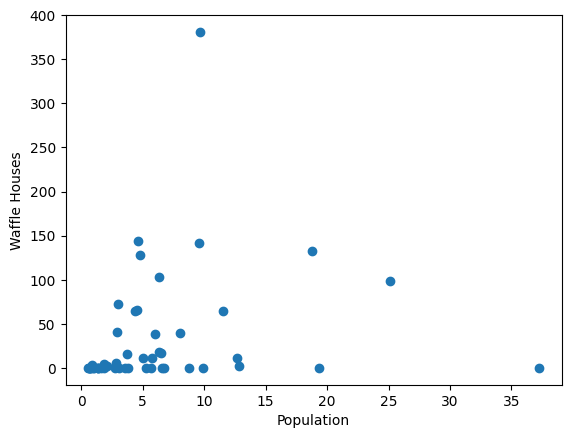

In [48]:
plt.ylabel("Waffle Houses")
plt.xlabel("Population")
plt.scatter(dset['Population'], dset['WaffleHouses'])

# Example model

In [49]:
def model(population=None, wafflehouses=None):
    a = numpyro.sample("a", dist.Normal(0, 1)) # 0,1 normal prior on slope
    b = numpyro.sample("b", dist.LogNormal(0, 1)) # 0,1 LogNormal prior on intercept
    population = numpyro.sample("population", dist.LogNormal(0,1), obs=population) # 0,1 LogNormal prior on population 
    line = a * population + b
    wafflehouses = numpyro.sample("waffle_houses", dist.Normal(line, 1), obs=wafflehouses)
    return wafflehouses

In [50]:
rng_key = random.PRNGKey(42)
rng_key, rng_key_ = random.split(rng_key)

In [54]:
with handlers.seed(rng_seed=1):
    x = numpyro.sample("x", dist.Normal(0,1))
y

TypeError: It looks like you tried to use a fn that isn't an instance of numpyro.distributions.Distribution, funsor.Funsor or tensorflow_probability.distributions.Distribution. If you're using funsor or tensorflow_probability, make sure they are correctly installed.